# ============================================================
# AI-Powered Financial Fraud Detection & Risk Analytics System
# Notebook 1: Data Understanding & Exploratory Data Analysis
# ============================================================

In [1]:
# =========================
# Import Libraries
# =========================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [2]:
# =========================
# Create Project Directories
# =========================

Path("../reports/figures").mkdir(
    parents=True,
    exist_ok=True
)

Path("../data/processed").mkdir(
    parents=True,
    exist_ok=True
)

In [3]:
# =========================
# Load Dataset
# =========================

df = pd.read_csv("../data/raw/paysim.csv")

print(f"Dataset Shape: {df.shape}")

df.head()

Dataset Shape: (6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
# =========================
# Dataset Overview
# =========================

rows, cols = df.shape

print(f"Total Rows    : {rows:,}")
print(f"Total Columns : {cols}")

Total Rows    : 6,362,620
Total Columns : 11


In [5]:
# Dataset Information

df.info()
# Numerical Statistics

df.describe().T
# Categorical Statistics

df.describe(include="object").T

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 706.2 MB


,count,unique,top,freq
type,6362620,5,CASH_OUT,2237500
nameOrig,6362620,6353307,C2098525306,3
nameDest,6362620,2722362,C1286084959,113


In [6]:
# =========================
# Data Quality Assessment
# =========================

missing_values = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing_values = missing_values[
    missing_values > 0
]

if missing_values.empty:
    print("No Missing Values Found")
else:
    display(missing_values)

No Missing Values Found


In [7]:
# Duplicate Records

duplicate_count = df.duplicated().sum()

print(f"Duplicate Rows: {duplicate_count:,}")

Duplicate Rows: 0


In [8]:
# =========================
# Fraud Distribution Analysis
# =========================

fraud_distribution = pd.DataFrame({
    "Count": df["isFraud"].value_counts(),
    "Percentage": round(
        df["isFraud"].value_counts(normalize=True) * 100,
        4
    )
})

fraud_distribution

,Count,Percentage
isFraud,,
0,6354407,99.8709
1,8213,0.1291


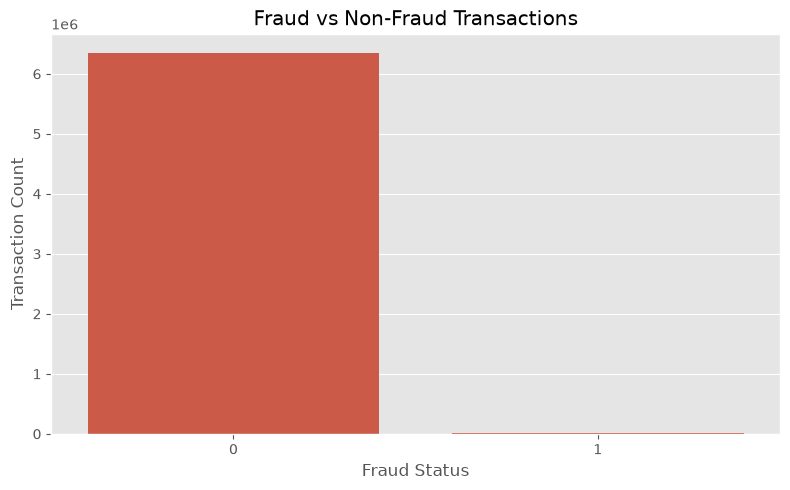

In [9]:
# Fraud Distribution Visualization

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="isFraud"
)

plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Fraud Status")
plt.ylabel("Transaction Count")

plt.tight_layout()

plt.savefig(
    "../reports/figures/fraud_vs_nonfraud.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [10]:
# =========================
# Transaction Type Analysis
# =========================

transaction_type_counts = (
    df["type"]
    .value_counts()
)

transaction_type_counts

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

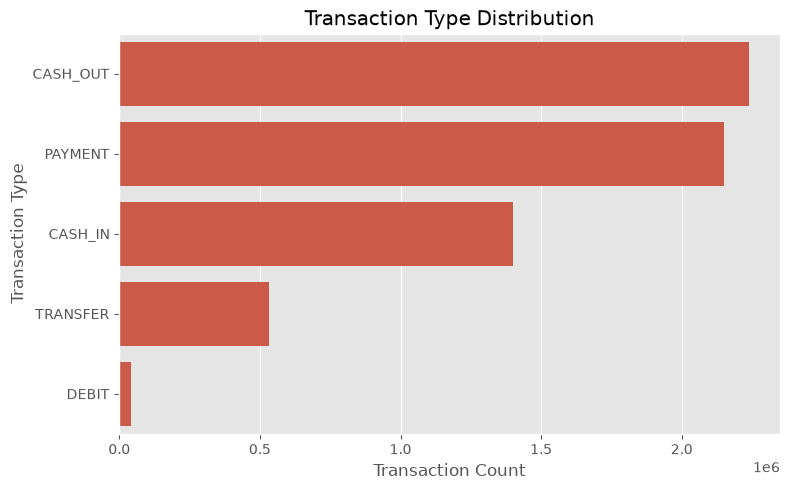

In [11]:
# Transaction Type Distribution

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    y="type",
    order=df["type"].value_counts().index
)

plt.title("Transaction Type Distribution")
plt.xlabel("Transaction Count")
plt.ylabel("Transaction Type")

plt.tight_layout()

plt.savefig(
    "../reports/figures/transaction_type_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [12]:
# Fraud Count by Transaction Type

fraud_type_analysis = pd.crosstab(
    df["type"],
    df["isFraud"]
)

fraud_type_analysis

isFraud,0,1
type,,
CASH_IN,1399284,0
CASH_OUT,2233384,4116
DEBIT,41432,0
PAYMENT,2151495,0
TRANSFER,528812,4097


In [13]:
# Fraud Percentage by Transaction Type

fraud_rate_by_type = (
    pd.crosstab(
        df["type"],
        df["isFraud"],
        normalize="index"
    ) * 100
)

fraud_rate_by_type

isFraud,0,1
type,,
CASH_IN,100.000000,0.000000
CASH_OUT,99.816045,0.183955
DEBIT,100.000000,0.000000
PAYMENT,100.000000,0.000000
TRANSFER,99.231201,0.768799


In [14]:
# =========================
# Transaction Amount Analysis
# =========================

df.groupby(
    "isFraud"
)["amount"].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,1.781970e+05,5.962370e+05,0.01,13368.395,74684.72,208364.76,92445516.64
1,8213.0,1.467967e+06,2.404253e+06,0.00,127091.330,441423.44,1517771.48,10000000.00


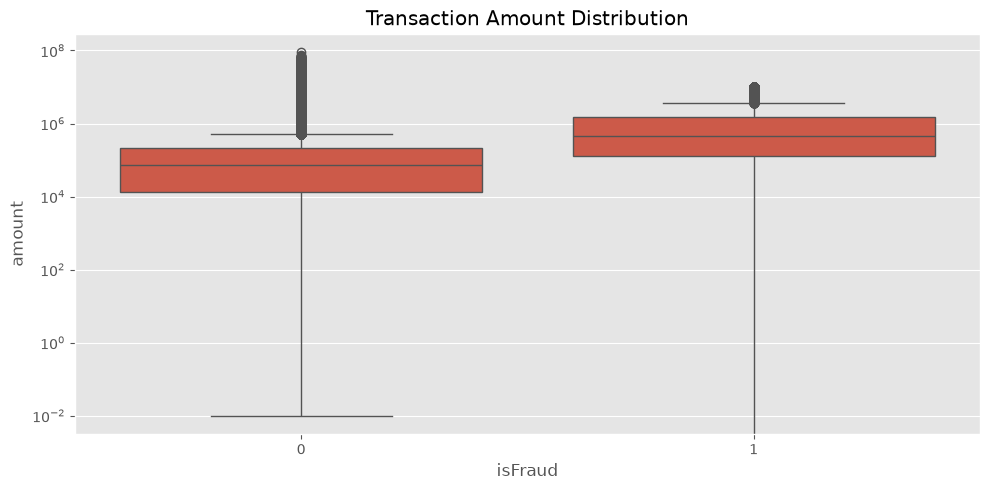

In [15]:
# Amount Distribution

plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x="isFraud",
    y="amount"
)

plt.yscale("log")

plt.title("Transaction Amount Distribution")

plt.tight_layout()

plt.savefig(
    "../reports/figures/transaction_amount_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [16]:
# =========================
# Correlation Analysis
# =========================

numeric_features = df.select_dtypes(
    include=["int64", "float64"]
)

correlation_matrix = numeric_features.corr()

correlation_matrix

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
step,1.000000,0.022373,-0.010058,-0.010299,0.027665,0.025888,0.031578,0.003277
amount,0.022373,1.000000,-0.002762,-0.007861,0.294137,0.459304,0.076688,0.012295
oldbalanceOrg,-0.010058,-0.002762,1.000000,0.998803,0.066243,0.042029,0.010154,0.003835
newbalanceOrig,-0.010299,-0.007861,0.998803,1.000000,0.067812,0.041837,-0.008148,0.003776
oldbalanceDest,0.027665,0.294137,0.066243,0.067812,1.000000,0.976569,-0.005885,-0.000513
newbalanceDest,0.025888,0.459304,0.042029,0.041837,0.976569,1.000000,0.000535,-0.000529
isFraud,0.031578,0.076688,0.010154,-0.008148,-0.005885,0.000535,1.000000,0.044109
isFlaggedFraud,0.003277,0.012295,0.003835,0.003776,-0.000513,-0.000529,0.044109,1.000000


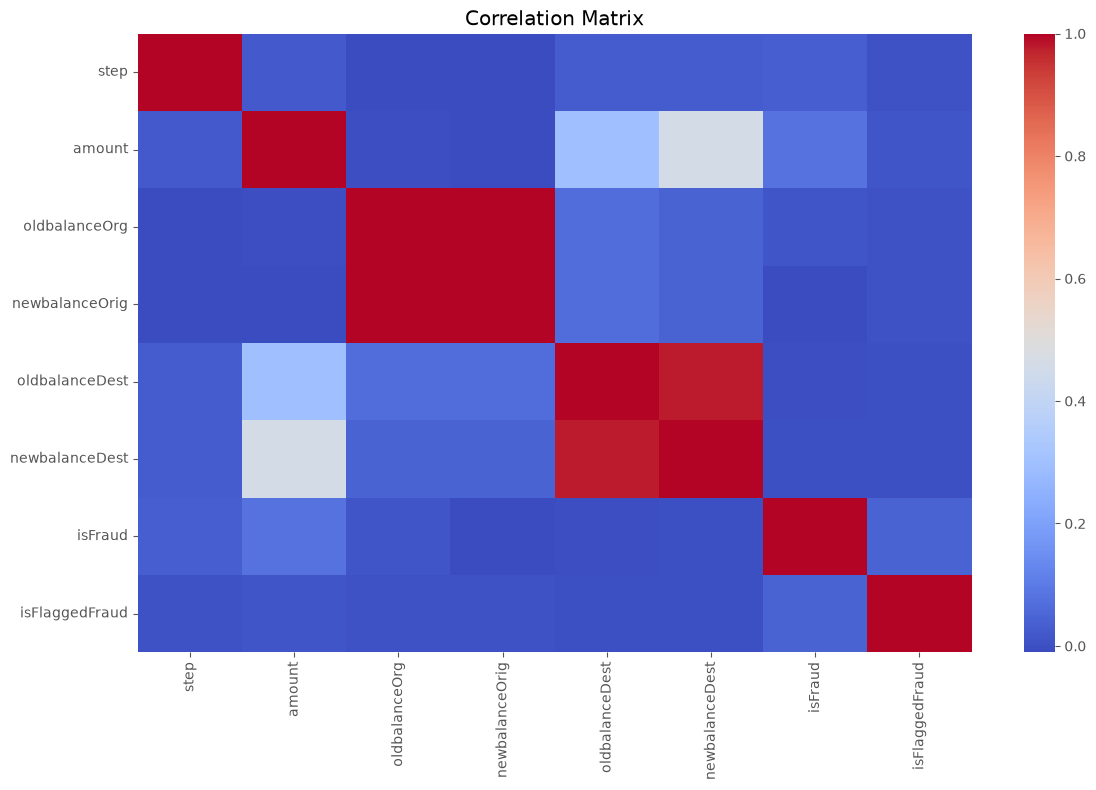

In [17]:
# Correlation Heatmap

plt.figure(figsize=(12,8))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.savefig(
    "../reports/figures/correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [18]:
# Feature Correlation with Target

fraud_correlation = (
    correlation_matrix["isFraud"]
    .sort_values(ascending=False)
)

fraud_correlation

isFraud           1.000000
amount            0.076688
isFlaggedFraud    0.044109
step              0.031578
oldbalanceOrg     0.010154
newbalanceDest    0.000535
oldbalanceDest   -0.005885
newbalanceOrig   -0.008148
Name: isFraud, dtype: float64

In [19]:
# =========================
# Business Insights
# =========================

print("1. Fraud transactions represent approximately 0.13% of all records.")
print("2. Dataset is highly imbalanced.")
print("3. TRANSFER and CASH_OUT are the highest-risk transaction types.")
print("4. Fraudulent transactions generally involve larger amounts.")
print("5. Balance-related variables show predictive potential.")
print("6. Additional engineered features may improve model performance.")

1. Fraud transactions represent approximately 0.13% of all records.
2. Dataset is highly imbalanced.
3. TRANSFER and CASH_OUT are the highest-risk transaction types.
4. Fraudulent transactions generally involve larger amounts.
5. Balance-related variables show predictive potential.
6. Additional engineered features may improve model performance.


In [20]:
# =========================
# Export EDA Summary
# =========================

eda_summary = pd.DataFrame({
    "total_rows": [len(df)],
    "total_columns": [df.shape[1]],
    "fraud_cases": [df["isFraud"].sum()],
    "fraud_percentage": [
        round(
            df["isFraud"].mean() * 100,
            4
        )
    ]
})

eda_summary.to_csv(
    "../data/processed/eda_summary.csv",
    index=False
)

print("EDA Summary Saved Successfully")

EDA Summary Saved Successfully


In [21]:
# =========================
# Notebook Completion
# =========================

print("Notebook 1 Completed Successfully")
print("Next Step: Data Preprocessing & Feature Engineering")

Notebook 1 Completed Successfully
Next Step: Data Preprocessing & Feature Engineering
